# 01 — Exploración visual del IPC España

Primera inspección visual de la serie de índice general y subgrupos ECOICOP.

**Entrada:** `data/processed/ipc_spain_index.parquet`

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ruta absoluta del notebook -> tfg-forecasting/ -> monorepo/
NOTEBOOK_DIR = Path(r"c:/Users/usuario/OneDrive/Documentos/tfg-ipc-mcp/tfg-forecasting/02_eda")
ROOT = NOTEBOOK_DIR.parent          # tfg-forecasting/
MONOREPO = ROOT.parent              # tfg-ipc-mcp/
sys.path.insert(0, str(MONOREPO))

from shared.constants import DATE_TRAIN_END, DATE_VAL_END, FREQ

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 1. Carga de datos

In [2]:
DATA_PATH = ROOT / "data" / "processed" / "ipc_spain_index.parquet"
df = pd.read_parquet(DATA_PATH)
print(f"Rango: {df.index.min().date()} -> {df.index.max().date()}")
print(f"Shape: {df.shape}")
df.head()

Rango: 2002-01-01 -> 2026-01-01
Shape: (289, 14)


,indice_general,01_alimentos_bebidas,02_bebidas_alcoholicas_tabaco,03_vestido_calzado,04_vivienda_agua_electricidad,05_muebles_hogar,06_sanidad,07_transporte,08_informacion_comunicaciones,09_ocio_cultura,10_ensenanza,11_restaurantes_alojamiento,12_seguros_servicios_financieros,13_cuidado_personal_proteccion_social
date,,,,,,,,,,,,,,
2002-01-01,58.717,49.796,38.396,77.799,51.962,71.792,80.484,56.407,229.772,68.671,53.641,51.100,48.925,62.617
2002-02-01,58.768,49.779,38.403,76.919,52.073,71.891,80.980,56.657,228.165,68.794,53.713,51.584,48.940,62.848
2002-03-01,59.253,50.042,38.475,78.553,52.208,72.194,81.321,57.467,226.617,70.197,53.774,52.092,48.993,63.204
2002-04-01,60.058,50.367,40.037,84.137,52.369,72.651,81.745,58.359,225.102,69.878,53.829,52.436,49.012,63.465
2002-05-01,60.274,50.585,40.141,85.050,52.458,72.959,81.322,58.512,221.751,70.347,53.835,52.624,49.019,63.690


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
indice_general,289.0,78.193076,10.498942,58.717,71.587,78.852,82.170,101.289
01_alimentos_bebidas,289.0,69.912637,12.972287,49.779,63.252,68.081,73.499,101.797
02_bebidas_alcoholicas_tabaco,289.0,69.556478,18.490770,38.396,50.307,77.208,82.281,103.245
03_vestido_calzado,289.0,90.855789,7.472154,76.673,84.027,92.140,96.066,108.042
04_vivienda_agua_electricidad,289.0,77.316291,13.689051,51.962,67.379,80.712,84.072,110.654
05_muebles_hogar,289.0,85.833471,7.139773,71.792,81.944,86.457,87.496,100.585
06_sanidad,289.0,88.872474,5.454803,79.900,83.788,90.636,92.445,101.052
07_transporte,289.0,79.793415,12.347033,56.407,70.354,81.252,85.745,105.418
08_informacion_comunicaciones,289.0,125.234765,32.926989,96.543,101.881,107.579,136.829,229.772
09_ocio_cultura,289.0,84.229270,7.637374,68.671,78.852,85.098,87.927,104.939


In [4]:
# Verificar frecuencia y gaps
expected = pd.date_range(df.index.min(), df.index.max(), freq="MS")
missing = expected.difference(df.index)
print(f"Meses esperados: {len(expected)}")
print(f"Meses presentes: {len(df)}")
print(f"Gaps: {len(missing)}")
if len(missing) > 0:
    print("Fechas faltantes:", missing.tolist())

Meses esperados: 289
Meses presentes: 289
Gaps: 0


## 2. Serie completa — Indice general

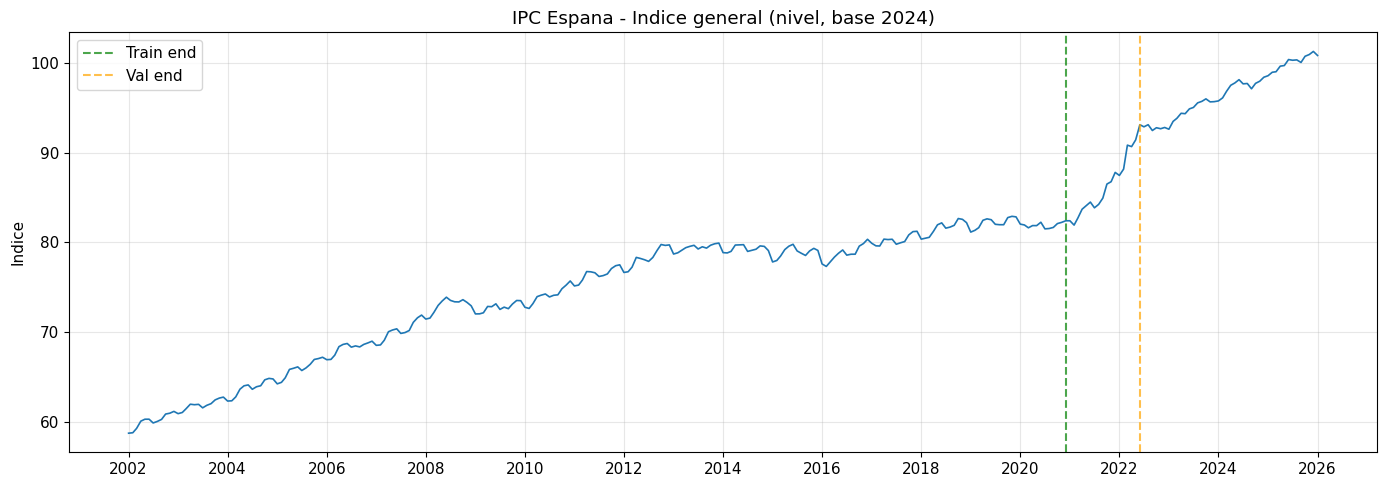

In [5]:
fig, ax = plt.subplots()
ax.plot(df.index, df["indice_general"], linewidth=1.2, color="#1f77b4")

# Lineas de corte train/val/test
for label, date, color in [
    ("Train end", DATE_TRAIN_END, "green"),
    ("Val end", DATE_VAL_END, "orange"),
]:
    ax.axvline(pd.Timestamp(date), color=color, linestyle="--", alpha=0.7, label=label)

ax.set_title("IPC Espana - Indice general (nivel, base 2024)")
ax.set_ylabel("Indice")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## 3. Variacion interanual (YoY %)

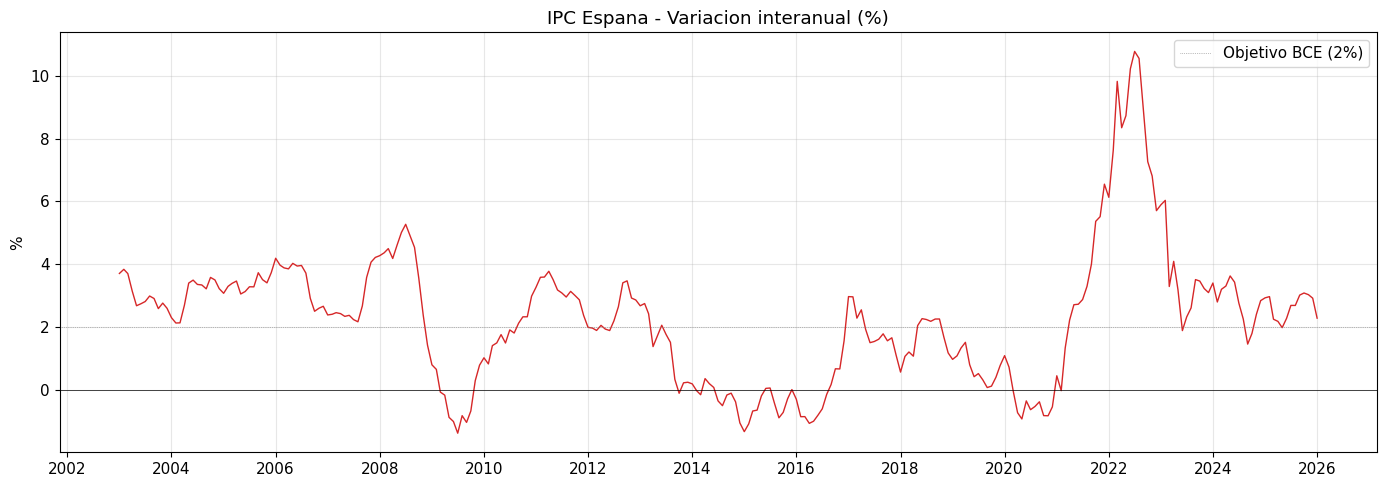

In [6]:
yoy = df["indice_general"].pct_change(12) * 100

fig, ax = plt.subplots()
ax.plot(yoy.index, yoy, linewidth=1, color="#d62728")
ax.axhline(0, color="black", linewidth=0.5)
ax.axhline(2, color="grey", linewidth=0.5, linestyle=":", label="Objetivo BCE (2%)")

ax.set_title("IPC Espana - Variacion interanual (%)")
ax.set_ylabel("%")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## 4. Todos los subgrupos ECOICOP

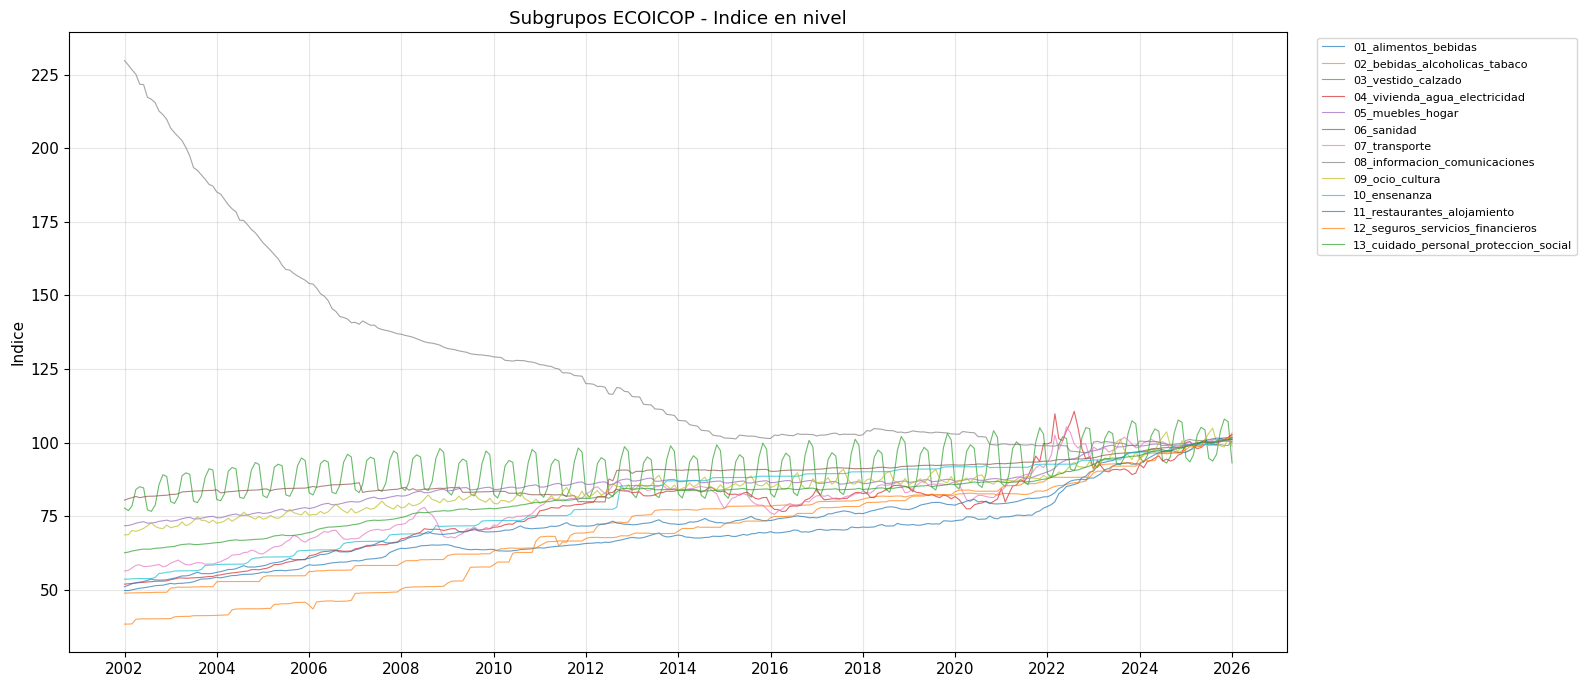

In [7]:
subgroups = [c for c in df.columns if c != "indice_general"]

fig, ax = plt.subplots(figsize=(16, 7))
for col in subgroups:
    ax.plot(df.index, df[col], linewidth=0.8, alpha=0.7, label=col)

ax.set_title("Subgrupos ECOICOP - Indice en nivel")
ax.set_ylabel("Indice")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## 5. Distribucion mensual (box plot)

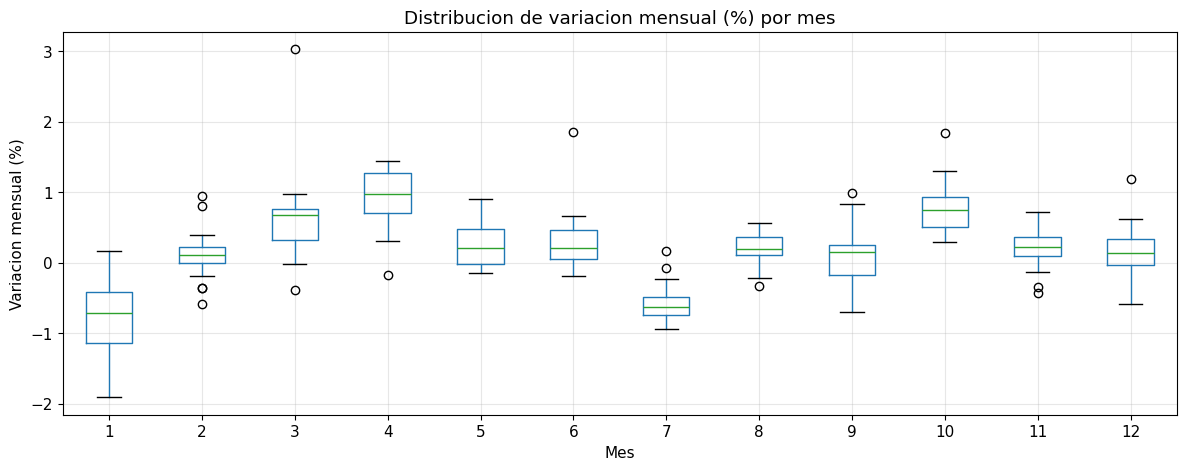

In [8]:
monthly_change = df["indice_general"].pct_change() * 100
monthly_df = pd.DataFrame({"month": df.index.month, "change_pct": monthly_change})

fig, ax = plt.subplots(figsize=(12, 5))
monthly_df.boxplot(column="change_pct", by="month", ax=ax)
ax.set_title("Distribucion de variacion mensual (%) por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Variacion mensual (%)")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 6. Splits train / val / test

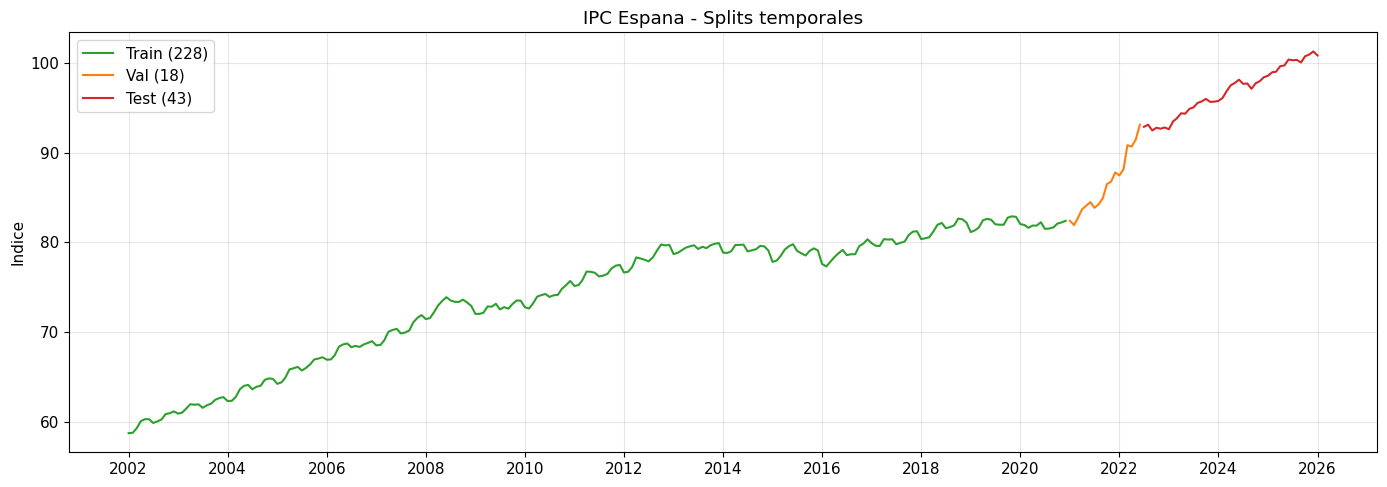

Train: 2002-01-01 -> 2020-12-01 (228 meses)
Val:   2021-01-01 -> 2022-06-01 (18 meses)
Test:  2022-07-01 -> 2026-01-01 (43 meses)


In [9]:
train = df.loc[:DATE_TRAIN_END]
val   = df.loc[DATE_TRAIN_END:DATE_VAL_END].iloc[1:]
test  = df.loc[DATE_VAL_END:].iloc[1:]

fig, ax = plt.subplots()
ax.plot(train.index, train["indice_general"], label=f"Train ({len(train)})", color="#2ca02c")
ax.plot(val.index, val["indice_general"], label=f"Val ({len(val)})", color="#ff7f0e")
ax.plot(test.index, test["indice_general"], label=f"Test ({len(test)})", color="#d62728")

ax.set_title("IPC Espana - Splits temporales")
ax.set_ylabel("Indice")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} meses)")
print(f"Val:   {val.index.min().date()} -> {val.index.max().date()} ({len(val)} meses)")
print(f"Test:  {test.index.min().date()} -> {test.index.max().date()} ({len(test)} meses)")

## 7. Resumen

In [10]:
print("="*60)
print("RESUMEN EXPLORACION IPC ESPANA")
print("="*60)
print(f"Rango temporal:    {df.index.min().date()} -> {df.index.max().date()}")
print(f"Total meses:       {len(df)}")
print(f"Frecuencia:        Mensual (MS)")
print(f"Gaps:              {len(missing)}")
print(f"NaN (idx general): {df['indice_general'].isna().sum()}")
print(f"Subgrupos:         {len(subgroups)}")
print(f"Min indice:        {df['indice_general'].min():.3f} ({df['indice_general'].idxmin().date()})")
print(f"Max indice:        {df['indice_general'].max():.3f} ({df['indice_general'].idxmax().date()})")
print("="*60)

RESUMEN EXPLORACION IPC ESPANA
Rango temporal:    2002-01-01 -> 2026-01-01
Total meses:       289
Frecuencia:        Mensual (MS)
Gaps:              0
NaN (idx general): 0
Subgrupos:         13
Min indice:        58.717 (2002-01-01)
Max indice:        101.289 (2025-12-01)
